In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
paths = []
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        paths.append(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-performance-multiple-linear-regression/Student_Performance.csv


# Multiple Linear Regression
## ML Lab 3
**Yasir Ahmad**  

**22MIA1064**

## Import data

In [2]:
df = pd.read_csv(paths[0])
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
df.shape

(10000, 6)

In [4]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [5]:
df.columns = df.columns.str.replace(' ', '_')

In [6]:
df.dtypes

Hours_Studied                         int64
Previous_Scores                       int64
Extracurricular_Activities           object
Sleep_Hours                           int64
Sample_Question_Papers_Practiced      int64
Performance_Index                   float64
dtype: object

In [7]:
df.isnull().sum()

Hours_Studied                       0
Previous_Scores                     0
Extracurricular_Activities          0
Sleep_Hours                         0
Sample_Question_Papers_Practiced    0
Performance_Index                   0
dtype: int64

In [8]:
df['Extracurricular_Activities'] = df['Extracurricular_Activities'].map({'Yes': 1, 'No': 0})

In [9]:
df.head()

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [10]:
df.describe()

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,0.494800,6.530600,4.583300,55.224800
std,2.589309,17.343152,0.499998,1.695863,2.867348,19.212558
min,1.000000,40.000000,0.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,0.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,0.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,1.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,1.000000,9.000000,9.000000,100.000000


## Raw MLR
raw implementation without feature selection

In [11]:
X0 = df.drop('Performance_Index',axis=1)
y0 = df['Performance_Index']

In [12]:
from sklearn.model_selection import train_test_split
X0_train,X0_test,y0_train,y0_test = train_test_split(X0,y0,test_size=0.3,random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression
Rmodel0 = LinearRegression()

In [14]:
Rmodel0.fit(X0_train,y0_train)

LinearRegression()

In [15]:
y0_pred = Rmodel0.predict(X0_test)

### Metrics of raw model

In [16]:
from sklearn import metrics

mae = metrics.mean_absolute_error(y0_test, y0_pred)
mse = metrics.mean_squared_error(y0_test, y0_pred)
r2 = metrics.r2_score(y0_test, y0_pred)

print("The raw model performance for testing set")
print("--------------------------------------")
print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('r2 is {}'.format(r2))

raw_model = {'mae':mae,'mse':mse,'r2':r2}

The raw model performance for testing set
--------------------------------------
MAE is 1.6090437564045217
MSE is 4.066563824092682
r2 is 0.9890110607021136


In [17]:
import statsmodels.api as sm
# Add a constant to the model (intercept)
X0 = sm.add_constant(X0)

# Fit the model
model0 = sm.OLS(y0, X0).fit()

# Print the summary
print(model0.summary())


                            OLS Regression Results                            
Dep. Variable:      Performance_Index   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 1.757e+05
Date:                Wed, 31 Jul 2024   Prob (F-statistic):               0.00
Time:                        04:47:11   Log-Likelihood:                -21307.
No. Observations:               10000   AIC:                         4.263e+04
Df Residuals:                    9994   BIC:                         4.267e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

## Visualize

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:2095: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` 

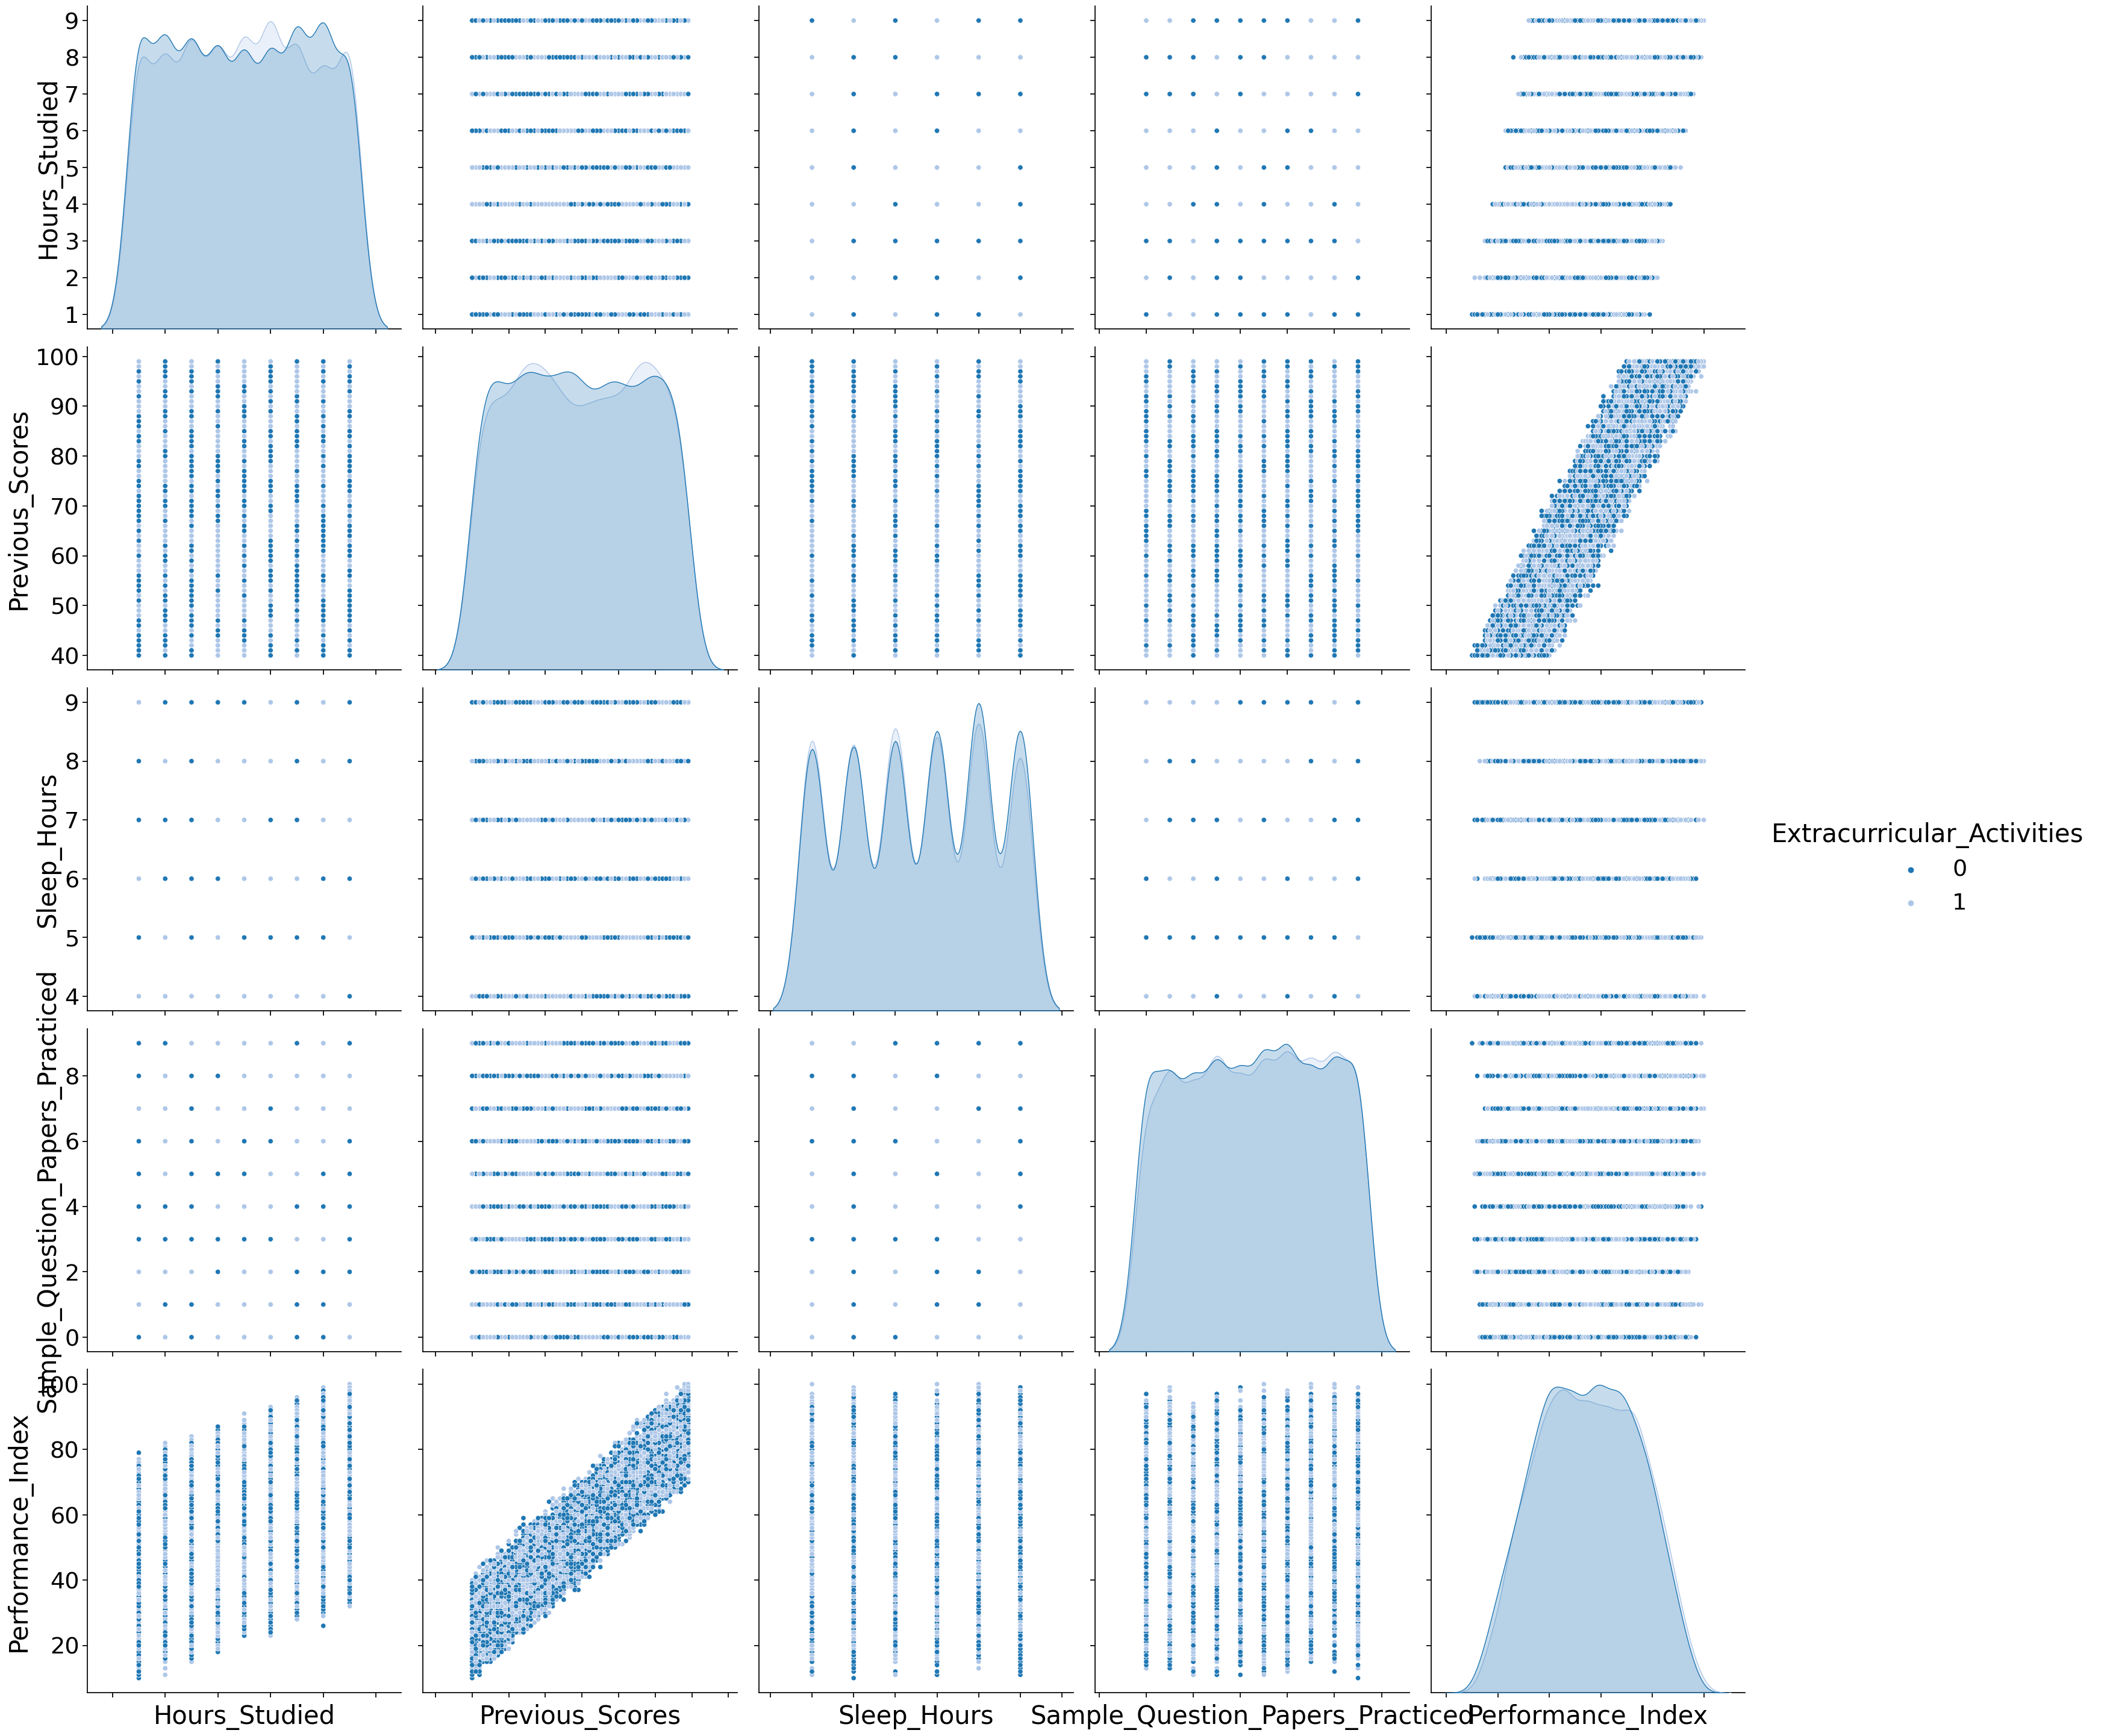

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

#understanding the distribution with seaborn
with sns.plotting_context("notebook",font_scale=2.5):
    g = sns.pairplot(df,hue='Extracurricular_Activities', palette='tab20',size=6)
g.set(xticklabels=[]);

<Axes: >

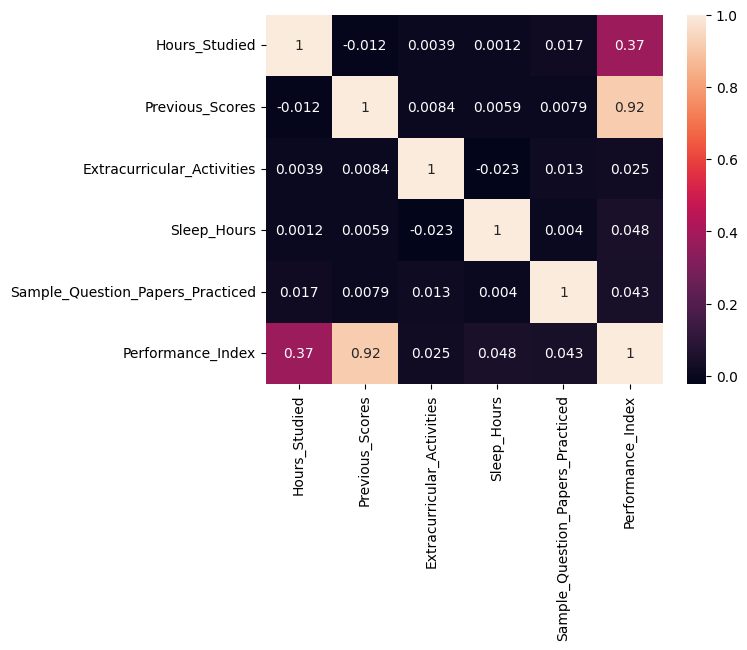

In [19]:
cor = df.corr()
sns.heatmap(cor,annot = True)

In [20]:
cor["Performance_Index"]

Hours_Studied                       0.373730
Previous_Scores                     0.915189
Extracurricular_Activities          0.024525
Sleep_Hours                         0.048106
Sample_Question_Papers_Practiced    0.043268
Performance_Index                   1.000000
Name: Performance_Index, dtype: float64

## ANOVA

In [21]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
for c in df.columns:
    mymod = ols(f'Performance_Index ~ {c}', data = df).fit()  
    # performing type 2 anova test  
    aovtable = sm.stats.anova_lm(mymod, typ = 2)  
    print(f'ANOVA table for Performance_Index ~ {c}')  
    print('------------------------------------------------------------------')  
    print(aovtable)  
    print()    

ANOVA table for Performance_Index ~ Hours_Studied
------------------------------------------------------------------
                     sum_sq      df            F  PR(>F)
Hours_Studied  5.155178e+05     1.0  1623.181225     0.0
Residual       3.175337e+06  9998.0          NaN     NaN

ANOVA table for Performance_Index ~ Previous_Scores
------------------------------------------------------------------
                       sum_sq      df             F  PR(>F)
Previous_Scores  3.091353e+06     1.0  51555.110025     0.0
Residual         5.995012e+05  9998.0           NaN     NaN

ANOVA table for Performance_Index ~ Extracurricular_Activities
------------------------------------------------------------------
                                  sum_sq      df         F    PR(>F)
Extracurricular_Activities  2.219950e+03     1.0  6.017146  0.014184
Residual                    3.688635e+06  9998.0       NaN       NaN

ANOVA table for Performance_Index ~ Sleep_Hours
-------------------------

In [22]:
mymod = ols(f'Performance_Index ~ Hours_Studied+Previous_Scores+Extracurricular_Activities+Sleep_Hours+Sample_Question_Papers_Practiced', data = df).fit()  
# performing type 2 anova test  
aovtable = sm.stats.anova_lm(mymod, typ = 2)  
print(f'ANOVA summary')  
print(aovtable)  
print()    

ANOVA summary
                                        sum_sq      df              F  \
Hours_Studied                     5.453996e+05     1.0  131300.003115   
Previous_Scores                   3.118438e+06     1.0  750735.576194   
Extracurricular_Activities        9.382547e+02     1.0     225.876318   
Sleep_Hours                       6.637009e+03     1.0    1597.799588   
Sample_Question_Papers_Practiced  3.085977e+03     1.0     742.920869   
Residual                          4.151351e+04  9994.0            NaN   

                                         PR(>F)  
Hours_Studied                      0.000000e+00  
Previous_Scores                    0.000000e+00  
Extracurricular_Activities         1.681087e-50  
Sleep_Hours                       4.940656e-324  
Sample_Question_Papers_Practiced  7.461573e-158  
Residual                                    NaN  



In [23]:
aovtable['F']

Hours_Studied                       131300.003115
Previous_Scores                     750735.576194
Extracurricular_Activities             225.876318
Sleep_Hours                           1597.799588
Sample_Question_Papers_Practiced       742.920869
Residual                                      NaN
Name: F, dtype: float64

In [24]:
X = df[['Hours_Studied','Previous_Scores']]
y = df['Performance_Index']

In [25]:
X

,Hours_Studied,Previous_Scores
0,7,99
1,4,82
2,8,51
3,5,52
4,7,75
...,...,...
9995,1,49
9996,7,64
9997,6,83
9998,9,97


In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [27]:
from sklearn.linear_model import LinearRegression
model2 = LinearRegression()
model2.fit(X_train, y_train)

LinearRegression()

In [28]:
# Predicting the Test set results
y_pred = model2.predict(X_test)

In [29]:
print(y_pred)

[54.831605   22.86662681 47.35061011 ... 33.4924078  66.37720887
 31.27613873]


## Regressor line

In [30]:
model2.coef_

array([2.86449217, 1.01615225])

In [31]:
model2.intercept_

-29.60536090045995

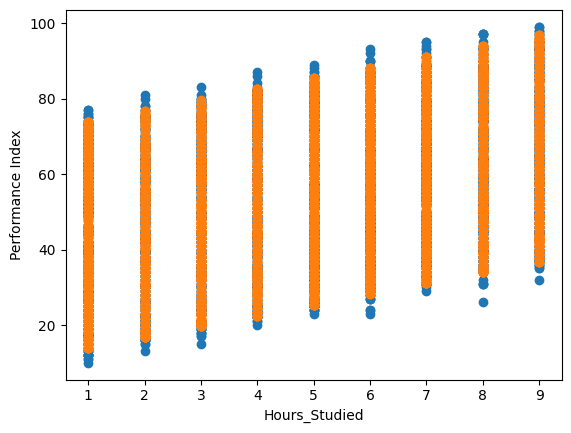

In [32]:
plt.scatter(X_test['Hours_Studied'],y_test)
plt.scatter(X_test['Hours_Studied'],y_pred)
plt.xlabel('Hours_Studied')
plt.ylabel('Performance Index')
plt.show()

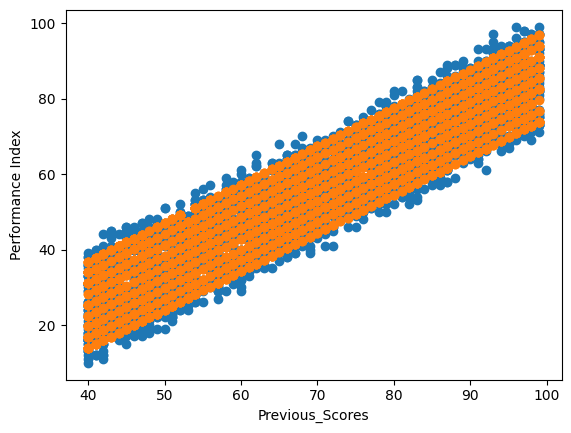

In [33]:
plt.scatter(X_test['Previous_Scores'],y_test)
plt.scatter(X_test['Previous_Scores'],y_pred)
plt.xlabel('Previous_Scores')
plt.ylabel('Performance Index')
plt.show()

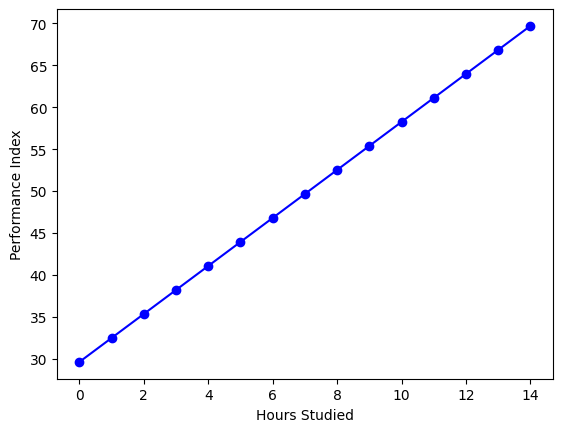

In [34]:
#xr = [-10:11]
x_values = np.arange(0,15)
y_values = model2.coef_[0] * x_values - model2.intercept_
plt.plot(x_values, y_values, label='Regression Line', linestyle='-', marker='o', color='b')
plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')
plt.show()

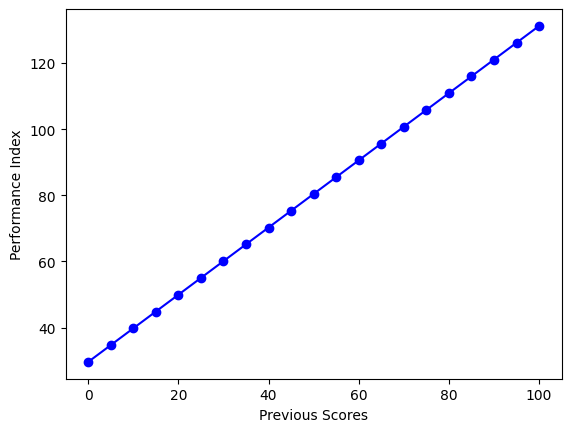

In [35]:
#xr = [-10:11]
x_values = np.arange(0,101,5)
y_values = model2.coef_[1] * x_values - model2.intercept_
plt.plot(x_values, y_values, label='Regression Line', linestyle='-', marker='o', color='b')
plt.xlabel('Previous Scores')
plt.ylabel('Performance Index')
plt.show()

In [36]:
# model evaluation for testing set
from sklearn import metrics

mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)

print("The model performance for testing set")
print("--------------------------------------")
print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('r2 is {}'.format(r2))

new_model = {'mae':mae,'mse':mse,'r2':r2}

The model performance for testing set
--------------------------------------
MAE is 1.8101437492369952
MSE is 5.201346140631689
r2 is 0.9859445764337783


In [37]:
import statsmodels.api as sm
# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print the summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Performance_Index   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                 3.488e+05
Date:                Wed, 31 Jul 2024   Prob (F-statistic):               0.00
Time:                        04:47:46   Log-Likelihood:                -22446.
No. Observations:               10000   AIC:                         4.490e+04
Df Residuals:                    9997   BIC:                         4.492e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -29.8168      0.105   -2

In [38]:
for i in raw_model:
    print(f"{i}")
    print(f"\traw: {raw_model[i]}")
    print(f"\tnew: {new_model[i]}")
    print(f"\tdiff: {raw_model[i]-new_model[i]}")

mae
	raw: 1.6090437564045217
	new: 1.8101437492369952
	diff: -0.20109999283247348
mse
	raw: 4.066563824092682
	new: 5.201346140631689
	diff: -1.1347823165390079
r2
	raw: 0.9890110607021136
	new: 0.9859445764337783
	diff: 0.0030664842683353344
